In [14]:
import pandas as pd

# Specify semicolon delimiter and appropriate engine
df = pd.read_csv('cardio_train.csv', sep=';', engine='python')

print(df.shape)    # Expect something like (70000, 14)
print(df.info())   # See correct column breakdown
df.head()


(70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [15]:
initial = len(df)
df.drop_duplicates(inplace=True)
print("Duplicates removed:", initial - len(df))


Duplicates removed: 0


In [16]:
dupes = df.duplicated().sum()
print("Duplicates:", dupes)

Duplicates: 0


In [17]:
df = df[df['height'].between(120,210)]
df = df[df['weight'].between(30,200)]
df = df[df['ap_hi'].between(80,250)]
df = df[df['ap_lo'].between(40,150)]


In [18]:
df['age_years'] = (df['age']/365).astype(int)
df['bmi'] = df['weight'] / (df['height']/100)**2
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']


In [19]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df.loc[:, ['ap_hi','ap_lo','bmi']] = imputer.fit_transform(df[['ap_hi','ap_lo','bmi']])


In [20]:
import pandas as pd

df = pd.get_dummies(df, columns=['cholesterol', 'gluc'], prefix=['chol', 'glu'], drop_first=True)
print(df.filter(like='chol').columns)  # shows new dummy cols


Index(['chol_2', 'chol_3'], dtype='object')


In [21]:
df.filter(regex='^(chol|glu)_').columns


Index(['chol_2', 'chol_3', 'glu_2', 'glu_3'], dtype='object')

In [22]:
import numpy as np

# The 'map' column doesn't exist in your DataFrame
# Either remove it from the list or make sure it's created before this code runs
num_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure']  # Removed 'map'

# Alternatively, if 'map' should be calculated from other columns, add it first
# For example, if 'map' is mean arterial pressure: (2*ap_lo + ap_hi)/3
# df['map'] = (2*df['ap_lo'] + df['ap_hi'])/3

means = df[num_cols].mean()
stds = df[num_cols].std()

print("Means (should be ~0):")
print(means.round(2).to_dict())
print("\nStds (should be ~1):")
print(stds.round(2).to_dict())

Means (should be ~0):
{'age_years': 52.83, 'height': 164.41, 'weight': 74.12, 'bmi': 27.46, 'ap_hi': 126.63, 'ap_lo': 81.35, 'pulse_pressure': 45.27}

Stds (should be ~1):
{'age_years': 6.77, 'height': 7.91, 'weight': 14.3, 'bmi': 5.26, 'ap_hi': 16.72, 'ap_lo': 9.54, 'pulse_pressure': 12.01}


In [24]:
# Calculate derived columns if not already present
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['map'] = (df['ap_hi'] + 2 * df['ap_lo']) / 3


In [25]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure', 'map']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Verify
means = df[num_cols].mean().round(2)
stds = df[num_cols].std().round(2)
print("Means:", means.to_dict())
print("Stds:", stds.to_dict())


Means: {'age_years': 0.0, 'height': -0.0, 'weight': -0.0, 'bmi': 0.0, 'ap_hi': 0.0, 'ap_lo': 0.0, 'pulse_pressure': -0.0, 'map': 0.0}
Stds: {'age_years': 1.0, 'height': 1.0, 'weight': 1.0, 'bmi': 1.0, 'ap_hi': 1.0, 'ap_lo': 1.0, 'pulse_pressure': 1.0, 'map': 1.0}


In [28]:
print(df.columns.tolist())


['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'pulse_pressure', 'chol_2', 'chol_3', 'glu_2', 'glu_3', 'map']


In [29]:
df['map'] = df['ap_lo'] + df['pulse_pressure'] / 3


In [30]:
num_cols = ['age_years', 'height', 'weight', 'bmi',
            'ap_hi', 'ap_lo', 'pulse_pressure', 'map']


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Verify the results
means = df[num_cols].mean().round(2)
stds = df[num_cols].std().round(2)
print("Means:", means.to_dict())
print("Stds:", stds.to_dict())


Means: {'age_years': 0.0, 'height': 0.0, 'weight': 0.0, 'bmi': 0.0, 'ap_hi': -0.0, 'ap_lo': -0.0, 'pulse_pressure': -0.0, 'map': -0.0}
Stds: {'age_years': 1.0, 'height': 1.0, 'weight': 1.0, 'bmi': 1.0, 'ap_hi': 1.0, 'ap_lo': 1.0, 'pulse_pressure': 1.0, 'map': 1.0}


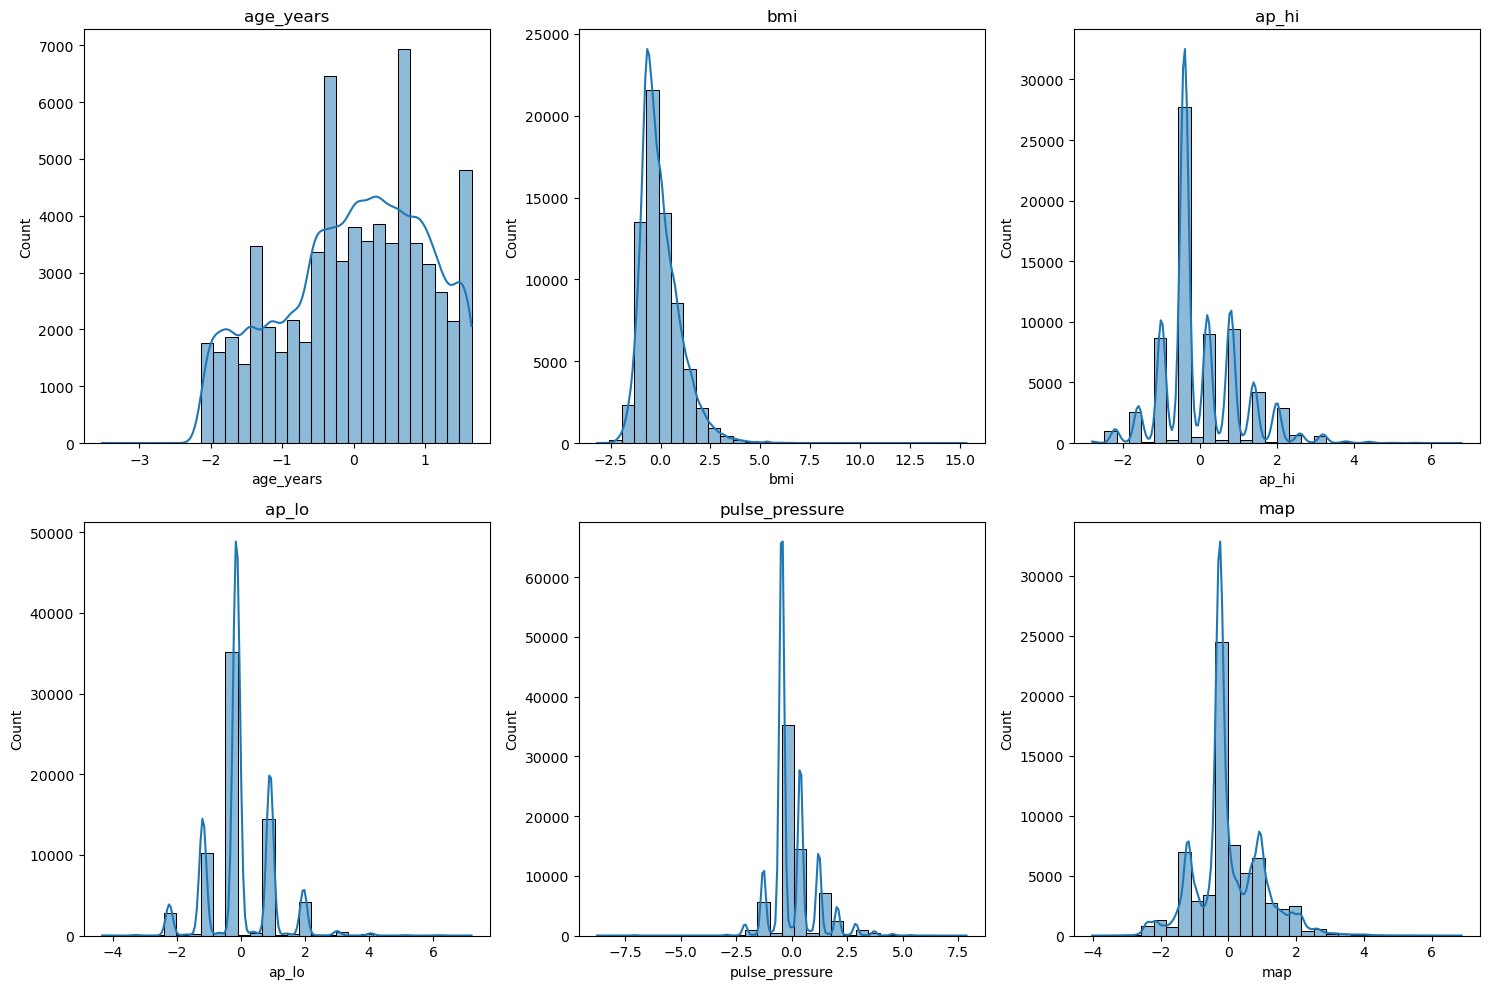

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure', 'map']
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axs.flatten(), num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


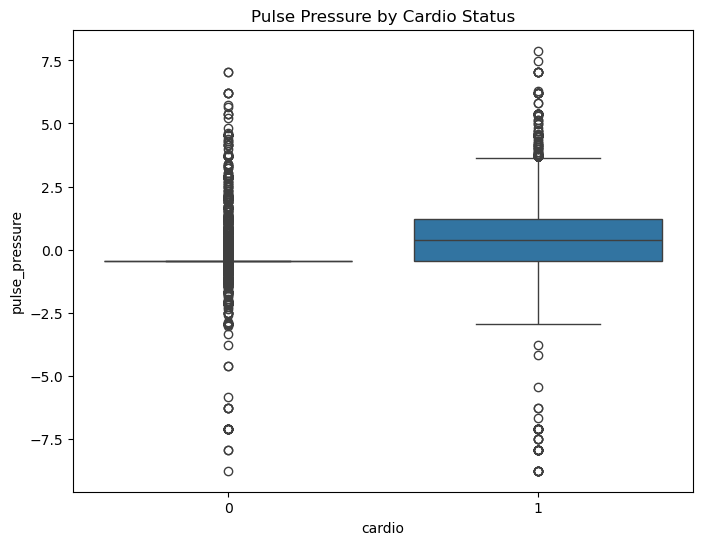

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='cardio', y='pulse_pressure', data=df)
plt.title('Pulse Pressure by Cardio Status')
plt.show()


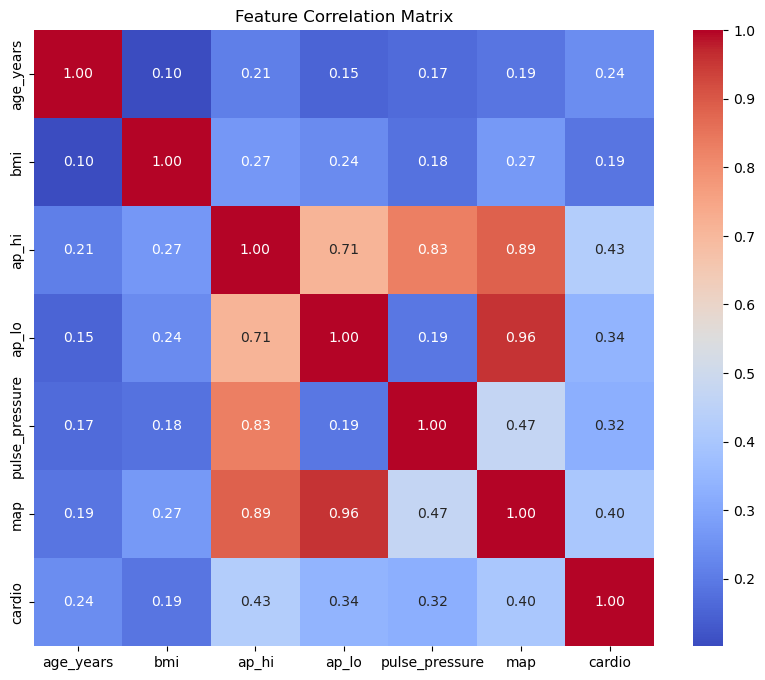

In [35]:
corr = df[num_cols + ['cardio']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


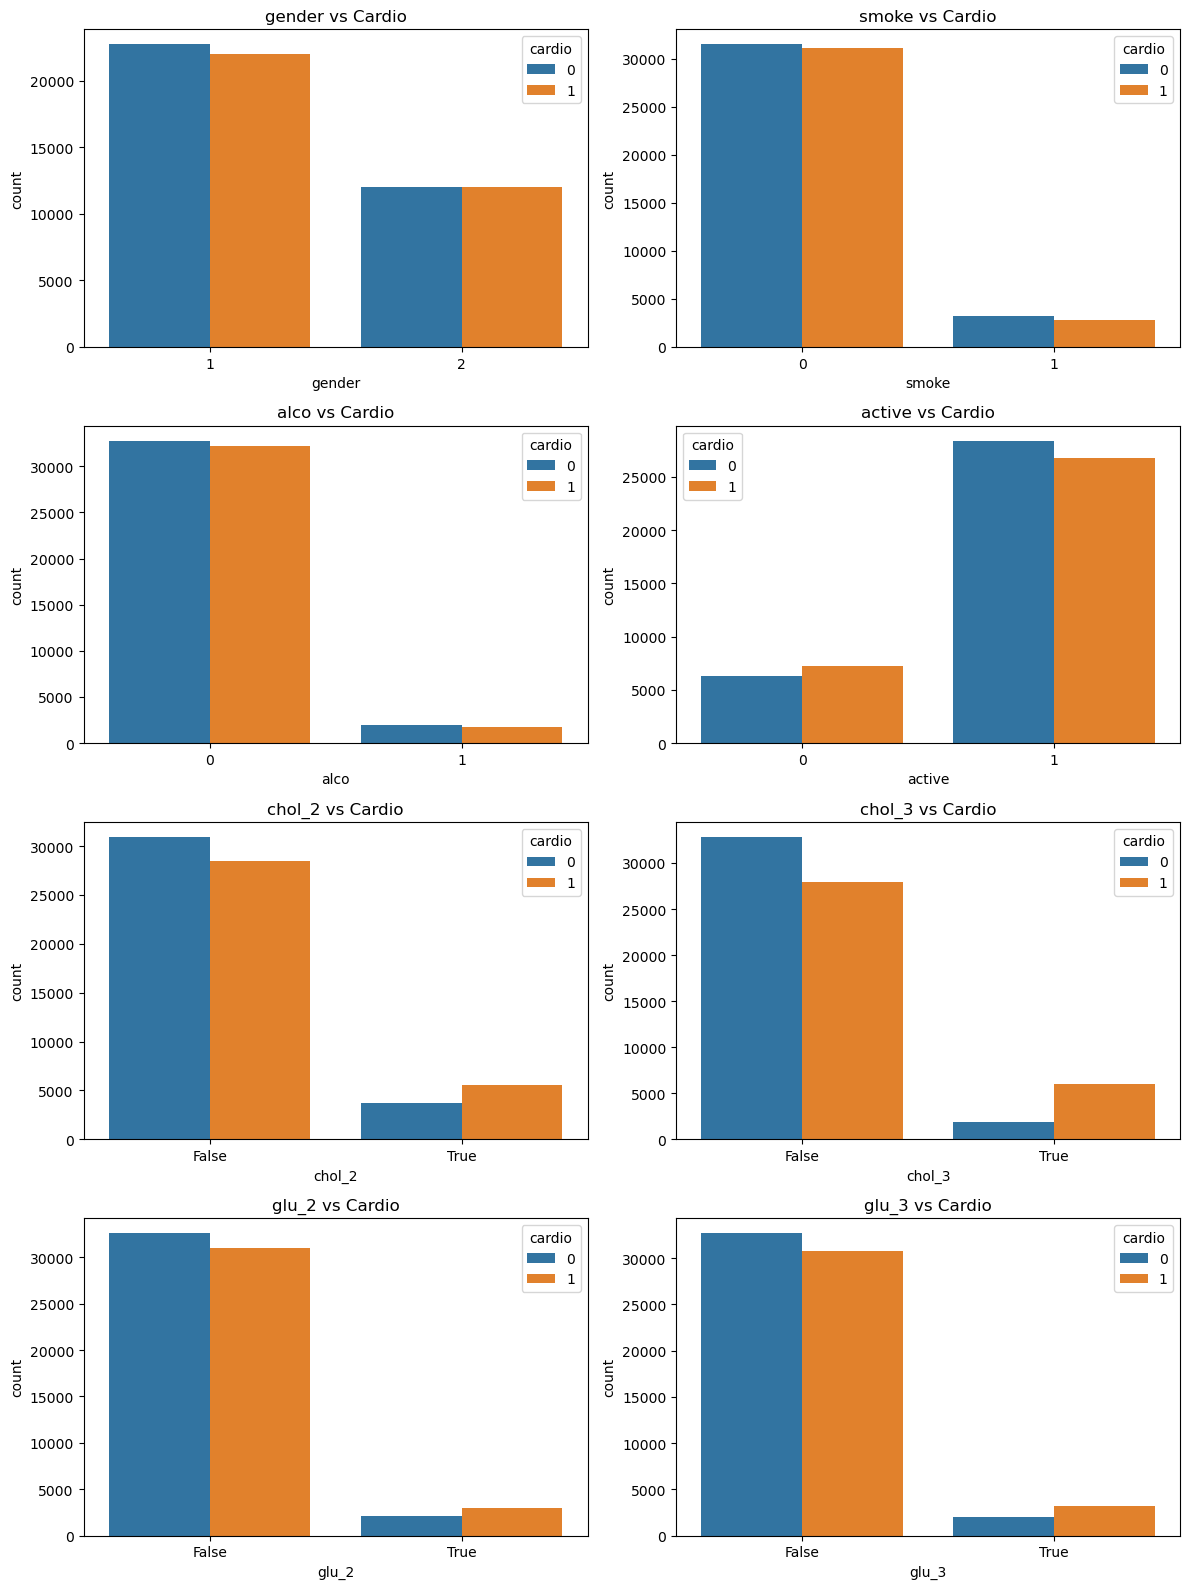

In [36]:
cat_cols = ['gender', 'smoke', 'alco', 'active', 'chol_2', 'chol_3', 'glu_2', 'glu_3']
fig, axs = plt.subplots(4, 2, figsize=(12, 16))
for ax, col in zip(axs.flatten(), cat_cols):
    sns.countplot(x=col, hue='cardio', data=df, ax=ax)
    ax.set_title(f'{col} vs Cardio')
plt.tight_layout()
plt.show()


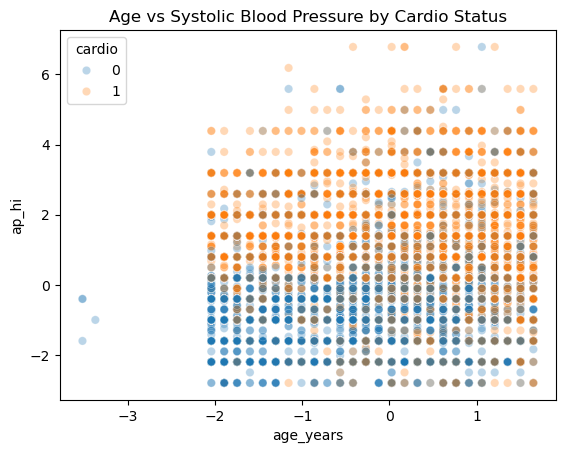

In [37]:
sns.scatterplot(x='age_years', y='ap_hi', hue='cardio', alpha=0.3, data=df)
plt.title('Age vs Systolic Blood Pressure by Cardio Status')
plt.show()


In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['id', 'cardio'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [39]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.0.2


Training Logistic Regression...

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        93
           1       0.91      0.80      0.86       107

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.86      0.85      0.86       200



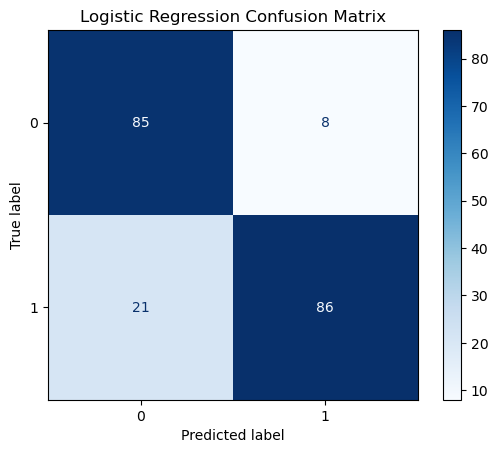

Training Decision Tree...

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        93
           1       0.93      0.83      0.88       107

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.88       200



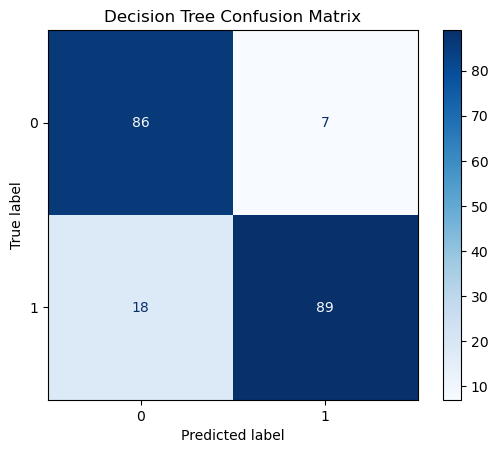

Training Random Forest...

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        93
           1       0.95      0.84      0.89       107

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.90      0.89      0.89       200



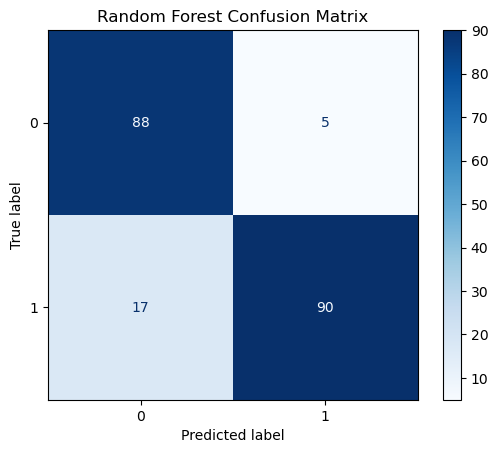

Training SVM...

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        93
           1       0.90      0.80      0.85       107

    accuracy                           0.84       200
   macro avg       0.85      0.85      0.84       200
weighted avg       0.85      0.84      0.85       200



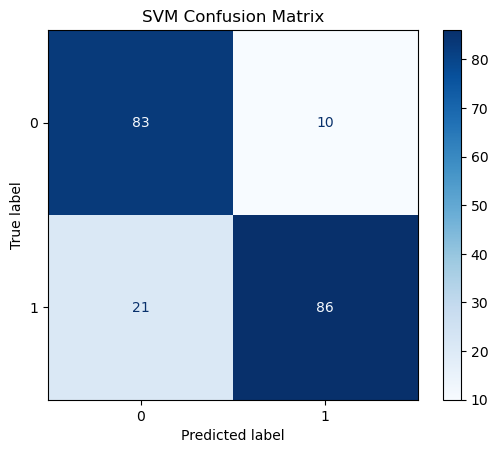

Training XGBoost...

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.89        93
           1       0.95      0.85      0.90       107

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.90       200



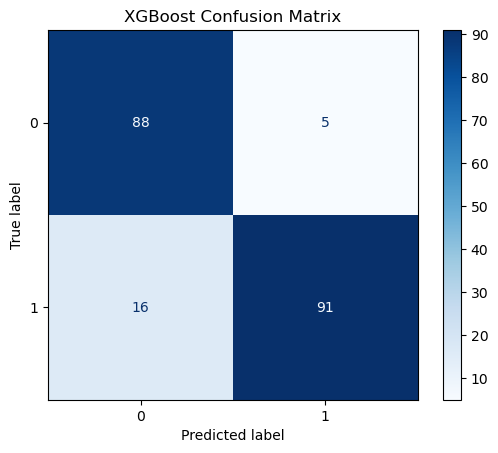

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Import additional libraries for data preparation
from sklearn.model_selection import train_test_split
import pandas as pd

# Load your data
# Replace this with your actual data loading code
# For example:
# df = pd.read_csv('your_dataset.csv')
# X = df.drop('target_column', axis=1)
# y = df['target_column']

# For demonstration purposes, let's create some dummy data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define your models in a dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# Train, predict and evaluate
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [7]:
import pandas as pd

df_results = pd.DataFrame(results).T  # transpose for readability
print(df_results)

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression     0.855   0.914894  0.803738  0.855721  0.921616
Decision Tree           0.875   0.927083  0.831776  0.876847  0.878253
Random Forest           0.890   0.947368  0.841121  0.891089  0.932369
SVM                     0.845   0.895833  0.803738  0.847291  0.923726
XGBoost                 0.895   0.947917  0.850467  0.896552  0.943523
